# Exploratory Data Analysis — Medical Insurance Charges

This notebook explores the [Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance) to understand the key factors driving insurance premiums before building our XGBoost prediction model.

**Key questions:**
1. What is the distribution of insurance charges?
2. How does smoker status affect premiums?
3. What is the relationship between BMI, age, and charges?
4. Are there regional differences in pricing?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

# Load data
df = pd.read_csv('../data/insurance.csv')
print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset: 1338 rows × 7 columns


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1⃣ Dataset Overview

In [2]:
print('--- Data Types ---')
print(df.dtypes)
print(f'\n--- Missing Values ---')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

--- Data Types ---
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

--- Missing Values ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing: 0


In [3]:
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


**Key observations:**
- No missing values — clean dataset
- Age ranges from 18 to 64
- BMI mean is ~30.6 (borderline obese by WHO standards)
- Charges are heavily right-skewed (mean >> median)

## 2⃣ Charges Distribution

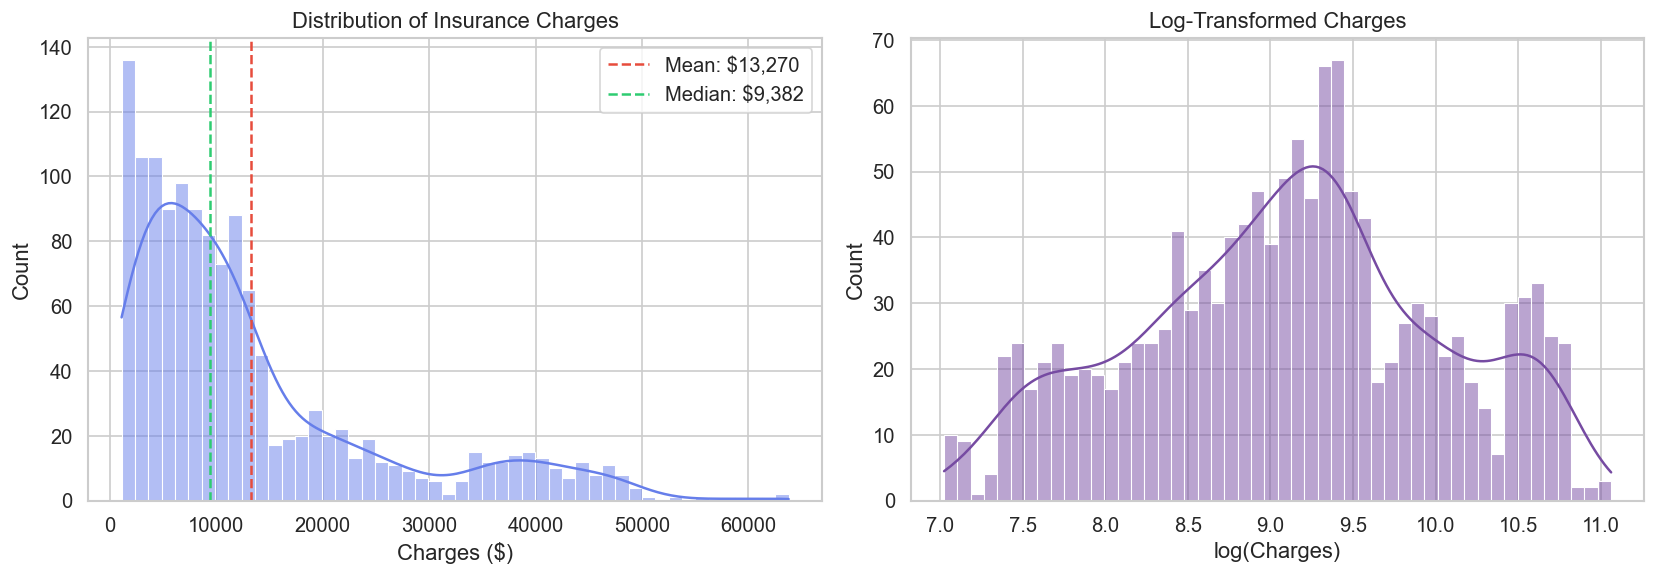

Skewness: 1.52
Kurtosis: 1.61


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
sns.histplot(df['charges'], bins=50, kde=True, color='#667eea', ax=axes[0])
axes[0].axvline(df['charges'].mean(), color='#E74C3C', linestyle='--', label=f"Mean: ${df['charges'].mean():,.0f}")
axes[0].axvline(df['charges'].median(), color='#2ECC71', linestyle='--', label=f"Median: ${df['charges'].median():,.0f}")
axes[0].set_title('Distribution of Insurance Charges')
axes[0].set_xlabel('Charges ($)')
axes[0].legend()

# Log-transformed
sns.histplot(np.log1p(df['charges']), bins=50, kde=True, color='#764ba2', ax=axes[1])
axes[1].set_title('Log-Transformed Charges')
axes[1].set_xlabel('log(Charges)')

plt.tight_layout()
plt.show()

print(f'Skewness: {df["charges"].skew():.2f}')
print(f'Kurtosis: {df["charges"].kurtosis():.2f}')

The raw charges distribution is **heavily right-skewed** (skewness > 1.5). The log transform reveals a multi-modal distribution — this hints at distinct subpopulations (spoiler: smokers vs. non-smokers).

## 3⃣ Smoker Status — The Dominant Factor

C:\Users\DN816\AppData\Local\Temp\ipykernel_28664\2516586167.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette=['#667eea', '#E74C3C'], ax=axes[0])
C:\Users\DN816\AppData\Local\Temp\ipykernel_28664\2516586167.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='smoker', y='charges', palette=['#667eea', '#E74C3C'], inner='quartile', ax=axes[1])


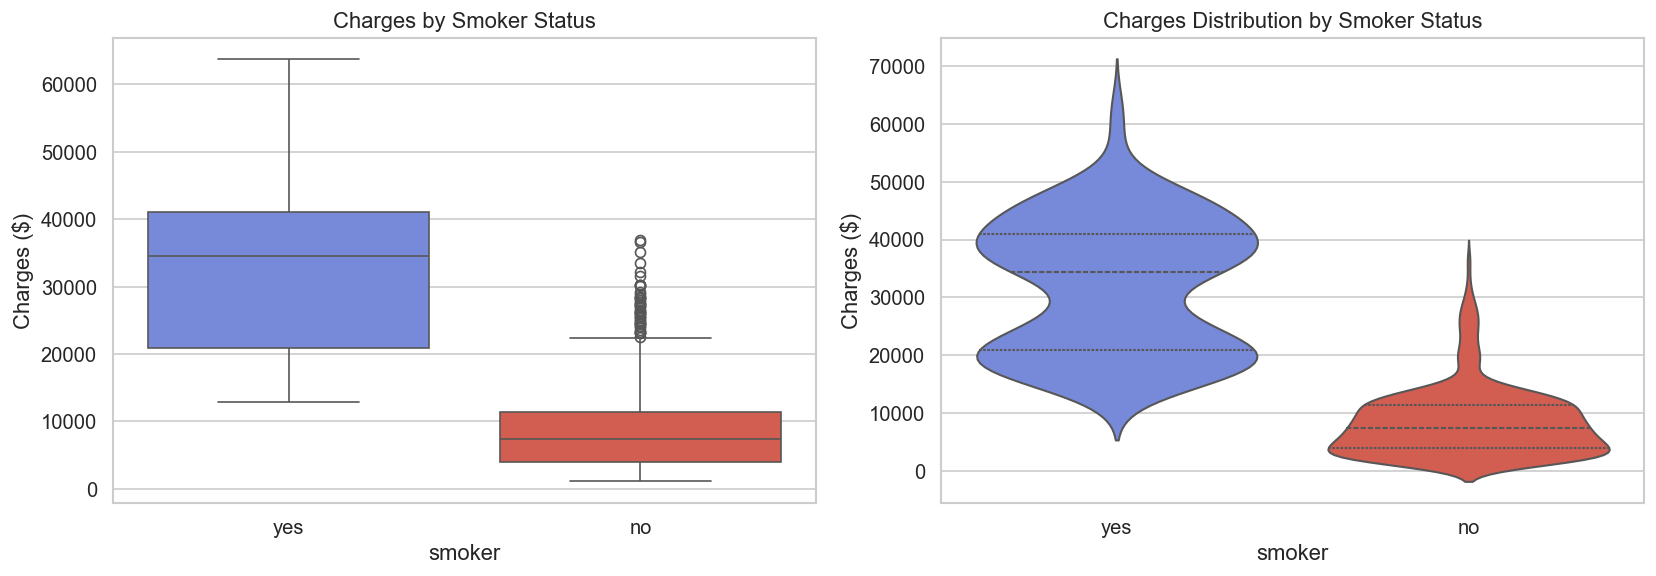

           mean   median  count
smoker                         
no       $8,434   $7,345   1064
yes     $32,050  $34,456    274

Smokers pay 3.8× more on average


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df, x='smoker', y='charges', palette=['#667eea', '#E74C3C'], ax=axes[0])
axes[0].set_title('Charges by Smoker Status')
axes[0].set_ylabel('Charges ($)')

# Violin plot with swarm
sns.violinplot(data=df, x='smoker', y='charges', palette=['#667eea', '#E74C3C'], inner='quartile', ax=axes[1])
axes[1].set_title('Charges Distribution by Smoker Status')
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

# Stats
smoker_stats = df.groupby('smoker')['charges'].agg(['mean', 'median', 'count'])
smoker_stats['mean'] = smoker_stats['mean'].map('${:,.0f}'.format)
smoker_stats['median'] = smoker_stats['median'].map('${:,.0f}'.format)
print(smoker_stats)
print(f'\nSmokers pay {df[df.smoker=="yes"]["charges"].mean() / df[df.smoker=="no"]["charges"].mean():.1f}× more on average')

**Smokers pay ~3.8× more** than non-smokers on average. This is the single most important feature in the dataset and will dominate our model.

## 4⃣ BMI vs. Charges — Colored by Smoker Status

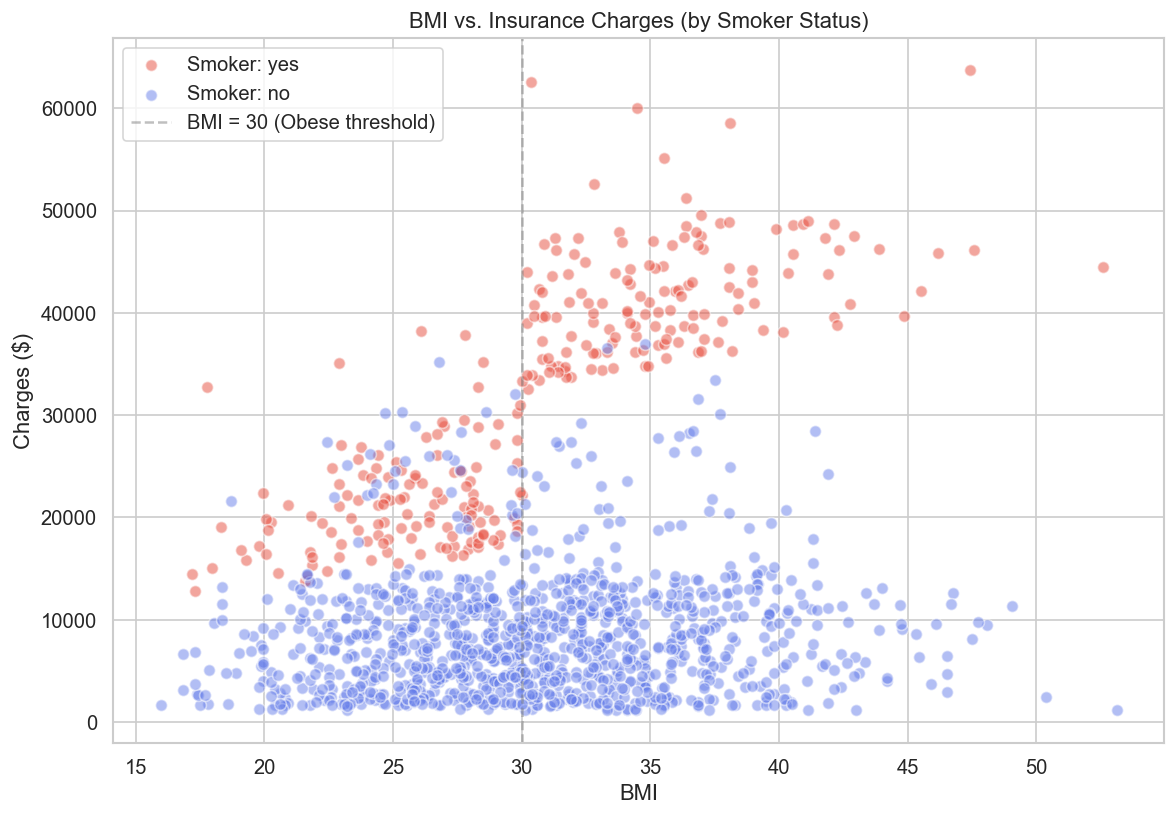

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = {'yes': '#E74C3C', 'no': '#667eea'}
for status, color in colors.items():
    mask = df['smoker'] == status
    ax.scatter(
        df.loc[mask, 'bmi'], df.loc[mask, 'charges'],
        c=color, alpha=0.5, label=f'Smoker: {status}', edgecolors='white', s=50
    )

# BMI threshold line
ax.axvline(x=30, color='gray', linestyle='--', alpha=0.5, label='BMI = 30 (Obese threshold)')

ax.set_xlabel('BMI')
ax.set_ylabel('Charges ($)')
ax.set_title('BMI vs. Insurance Charges (by Smoker Status)')
ax.legend()
plt.tight_layout()
plt.show()

**Critical insight:** For smokers with BMI > 30, there's a sharp jump in charges — this is the **smoker × BMI interaction** effect. Non-smokers show a much flatter relationship with BMI. This justifies our `smoker_bmi` interaction feature.

## 5⃣ Age vs. Charges

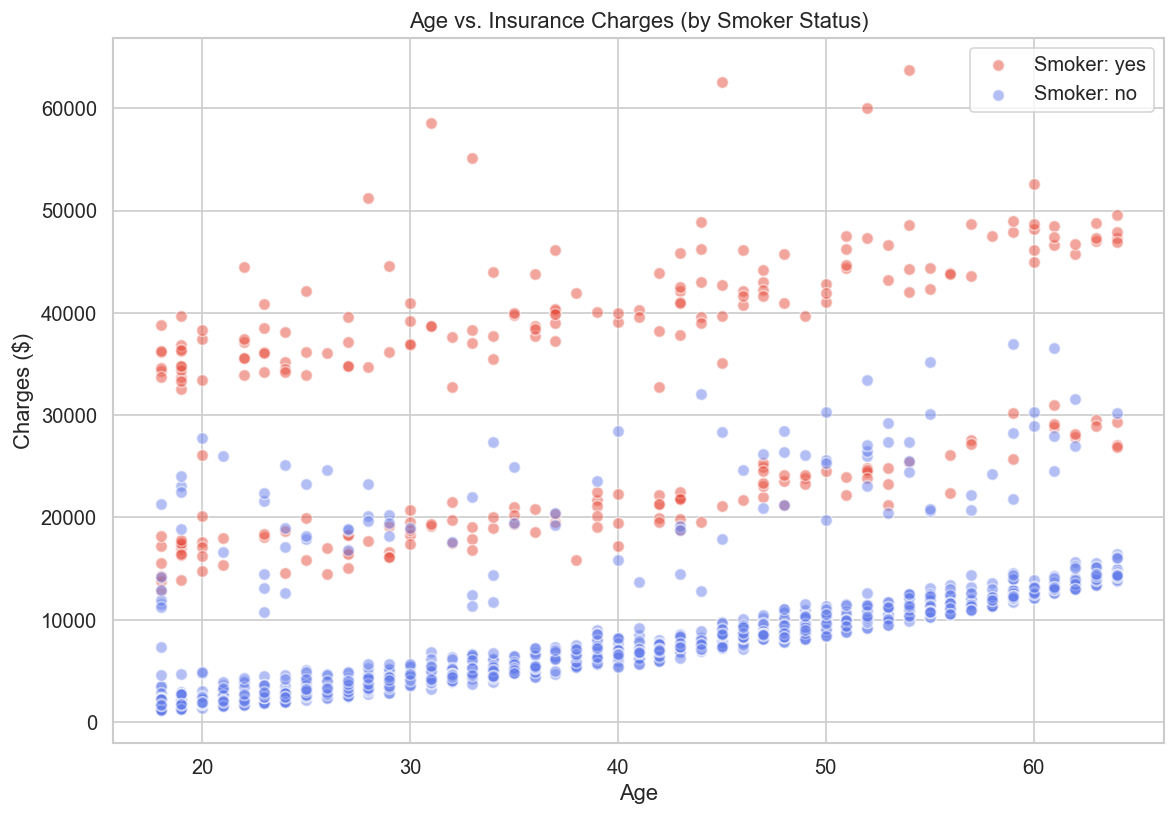

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

for status, color in colors.items():
    mask = df['smoker'] == status
    ax.scatter(
        df.loc[mask, 'age'], df.loc[mask, 'charges'],
        c=color, alpha=0.5, label=f'Smoker: {status}', edgecolors='white', s=50
    )

ax.set_xlabel('Age')
ax.set_ylabel('Charges ($)')
ax.set_title('Age vs. Insurance Charges (by Smoker Status)')
ax.legend()
plt.tight_layout()
plt.show()

Three distinct bands are visible:
1. **Bottom band** — Non-smokers (low charges, linear increase with age)
2. **Middle band** — Smokers with lower BMI
3. **Top band** — Smokers with high BMI (the most expensive segment)

Age has a near-linear relationship with charges for non-smokers, justifying the `smoker_age` interaction feature.

## 6⃣ Correlation Heatmap

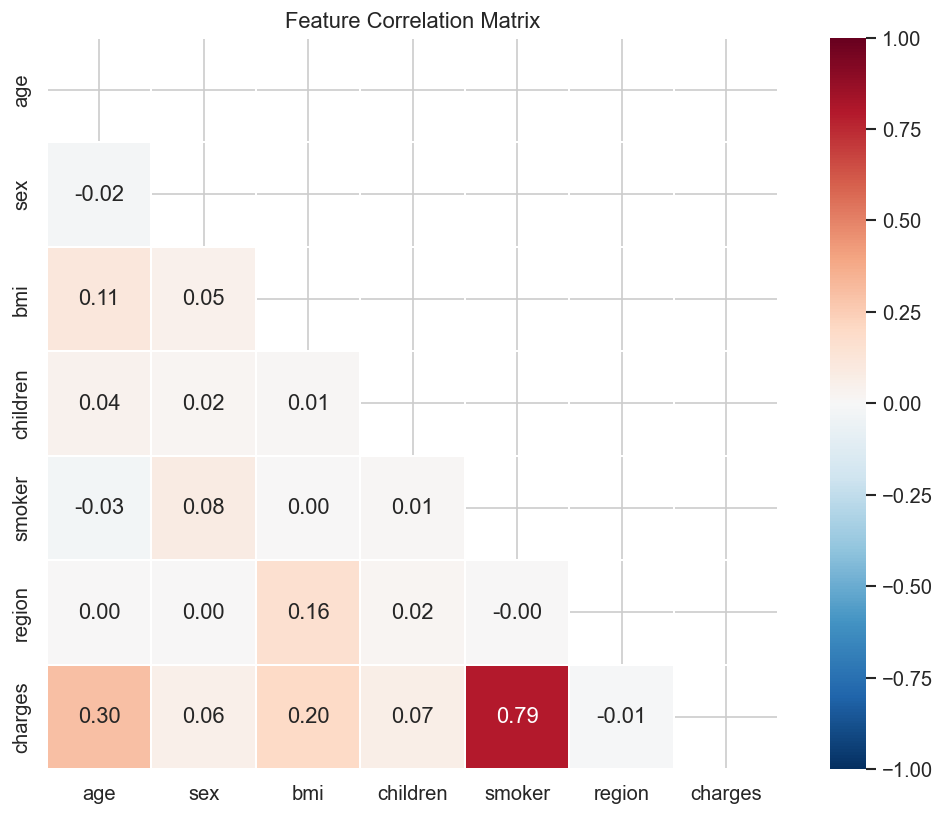

In [8]:
# Encode categoricals for correlation
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
df_encoded['region'] = df_encoded['region'].astype('category').cat.codes

fig, ax = plt.subplots(figsize=(9, 7))
corr = df_encoded.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, cmap='RdBu_r', center=0,
    square=True, linewidths=1, fmt='.2f', ax=ax,
    vmin=-1, vmax=1
)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Smoker** has the highest correlation with charges (r ≈ 0.79). Age (r ≈ 0.30) and BMI (r ≈ 0.20) show moderate correlations. Sex and region have negligible linear correlation with charges.

## 7⃣ Regional & Demographic Breakdown

C:\Users\DN816\AppData\Local\Temp\ipykernel_28664\1441793779.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='charges', palette='viridis', ax=axes[0])
C:\Users\DN816\AppData\Local\Temp\ipykernel_28664\1441793779.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='charges', palette=['#667eea', '#E74C3C'], ax=axes[1])
C:\Users\DN816\AppData\Local\Temp\ipykernel_28664\1441793779.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='children', y='charges', palette='coolwarm', ax=axes[2])

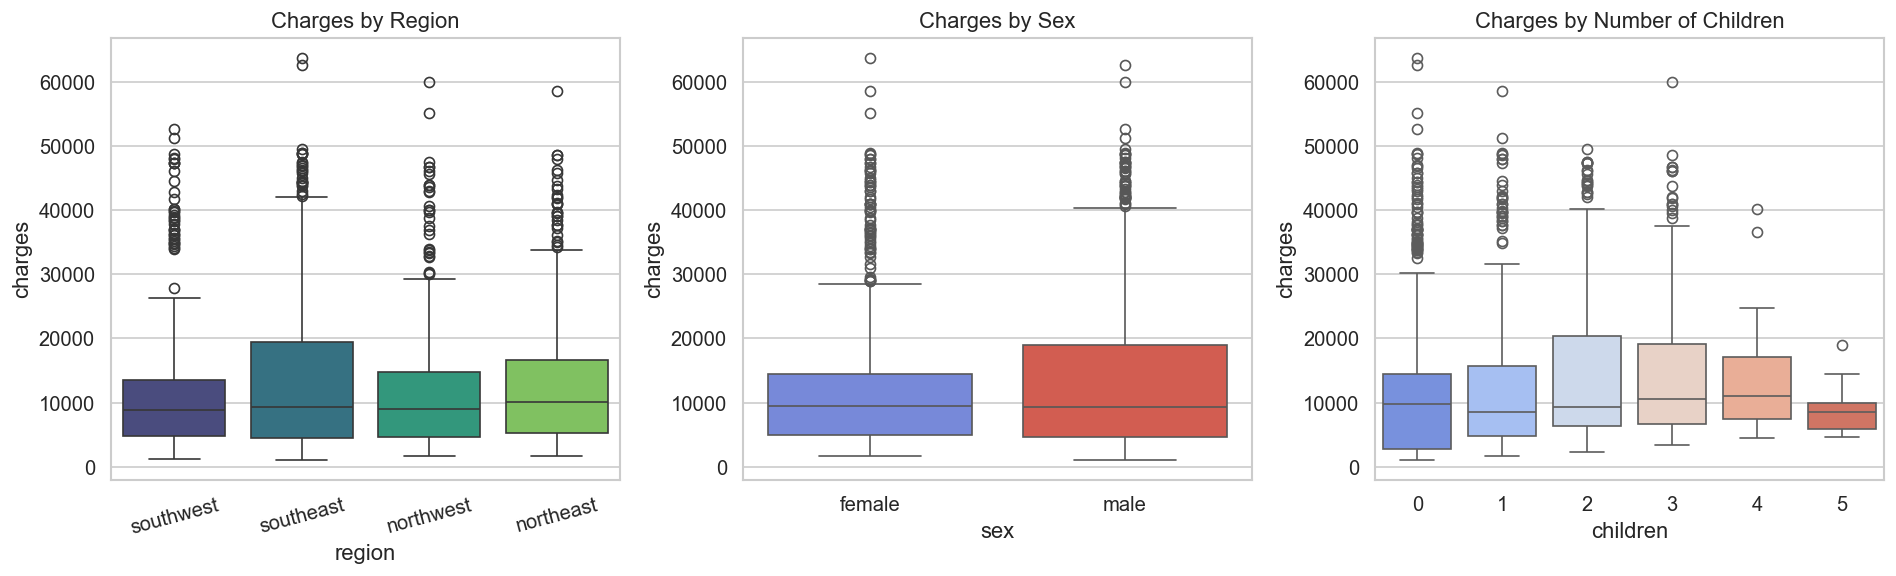

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By region
sns.boxplot(data=df, x='region', y='charges', palette='viridis', ax=axes[0])
axes[0].set_title('Charges by Region')
axes[0].tick_params(axis='x', rotation=15)

# By sex
sns.boxplot(data=df, x='sex', y='charges', palette=['#667eea', '#E74C3C'], ax=axes[1])
axes[1].set_title('Charges by Sex')

# By number of children
sns.boxplot(data=df, x='children', y='charges', palette='coolwarm', ax=axes[2])
axes[2].set_title('Charges by Number of Children')

plt.tight_layout()
plt.show()

## Key Takeaways

| Finding | Implication |
|---|---|
| Smokers pay **3.8×** more on average | `smoker` is the #1 predictor |
| BMI > 30 + smoking creates a cost spike | Need `smoker × bmi` interaction feature |
| Age has near-linear effect for non-smokers | Need `smoker × age` interaction feature |
| Charges are heavily right-skewed | XGBoost handles this well (tree-based, no normality assumption) |
| Sex and region have minimal impact | Low importance, but kept for completeness |
| No missing values | No imputation needed |

**Next steps:** Build the XGBoost model in `src/train.py` with the engineered interaction features identified above.